<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/MDF_Conducao_2D_Simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

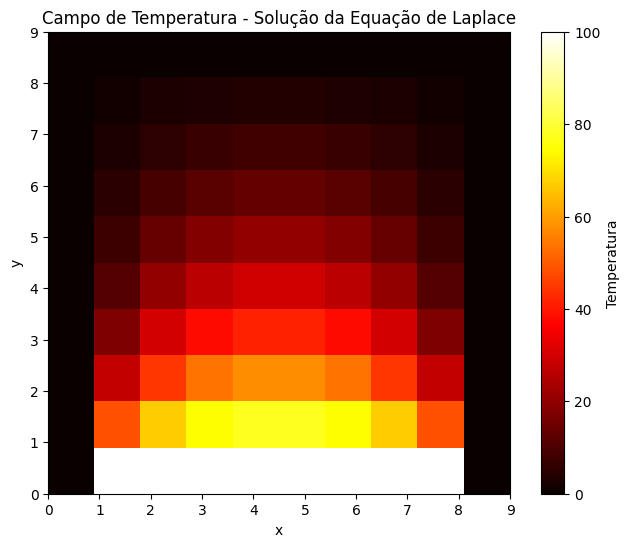

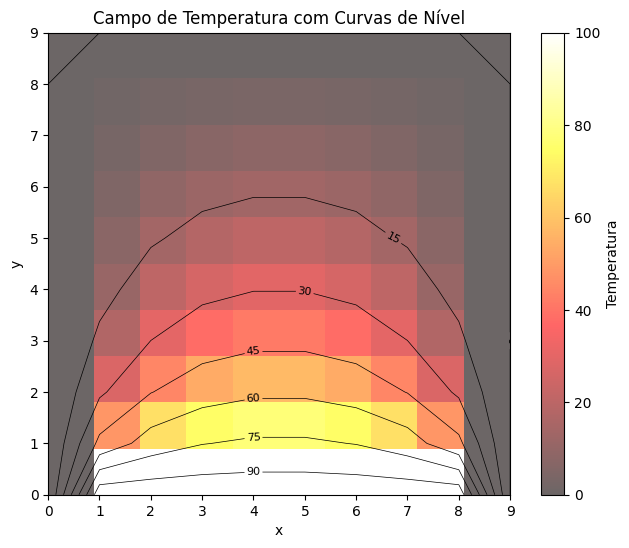

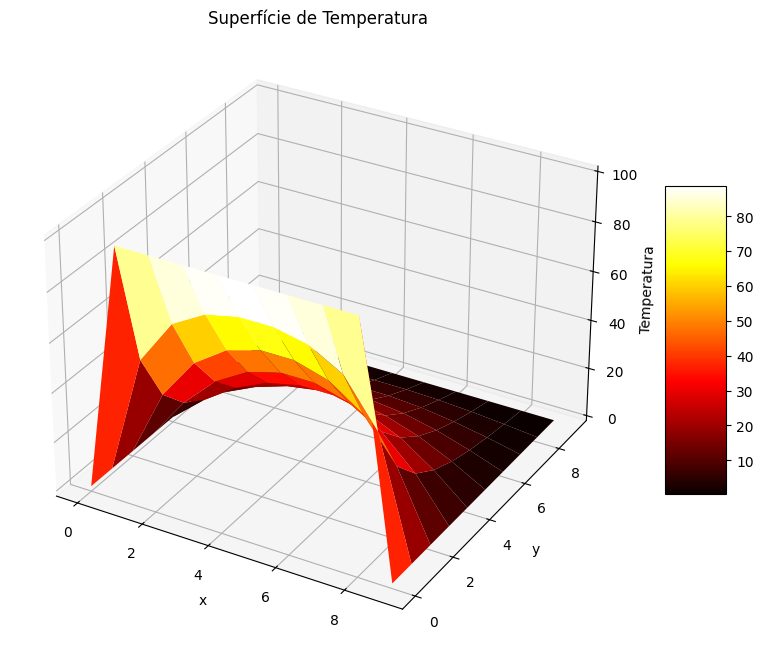

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Nx, Ny = 10, 10  # número de pontos internos + contornos
h = 1.0
T = np.zeros((Ny, Nx))

# Aplicar condições de contorno (exemplo)
T[0, :] = 100   # contorno superior
T[-1, :] = 0    # inferior
T[:, 0] = 0     # esquerda
T[:, -1] = 0    # direita

# Iteração Gauss-Seidel para resolver
for _ in range(10000):
    T_old = T.copy()
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            T[j, i] = 0.25 * (T[j, i+1] + T[j, i-1] + T[j+1, i] + T[j-1, i])
    if np.max(np.abs(T - T_old)) < 1e-6:
        break

# Plotar o campo de temperatura em 2D
plt.figure(figsize=(8, 6))
plt.imshow(T, origin='lower', cmap='hot', extent=[0, Nx-1, 0, Ny-1])
plt.colorbar(label='Temperatura')
plt.title('Campo de Temperatura - Solução da Equação de Laplace')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Opcional: Plot com contornos
plt.figure(figsize=(8, 6))
contour = plt.contour(T, extent=[0, Nx-1, 0, Ny-1], colors='black', linewidths=0.5)
plt.clabel(contour, inline=True, fontsize=8)
plt.imshow(T, origin='lower', cmap='hot', alpha=0.6, extent=[0, Nx-1, 0, Ny-1])
plt.colorbar(label='Temperatura')
plt.title('Campo de Temperatura com Curvas de Nível')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Opcional: Plot 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(Nx)
y = np.arange(Ny)
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, T, cmap='hot', linewidth=0, antialiased=True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Temperatura')
ax.set_title('Superfície de Temperatura')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()